# 04 — A Harder Validation Split, and Graph Features

The Random Forest baseline scored **0.997** on validation but only **0.934** on the public leaderboard. This notebook:

1. finds out why validation was so optimistic, and adds a harder validation split;
2. tests a graph feature (degree);
3. records the other ideas that were tried and dropped.

In [1]:
import sys, warnings
from datetime import date
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

from src.data import load_train, load_edges, FEATURE_COLS, ID_COL, SEED
from src.validation import evaluate, log_experiment, HARD_TRAIN_END
from src.features import degree_features

TODAY, NOTEBOOK = date.today().isoformat(), "04_graph_features"
C_A, C_B, C_MUTED = "#2a78d6", "#eb6834", "#898781"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": C_MUTED, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})

train, edges = load_train(), load_edges()

def lgbm(seed=SEED):
    """The LightGBM configuration used throughout this notebook (best public LB so far, 0.948)."""
    return LGBMClassifier(n_estimators=500, learning_rate=0.02, num_leaves=15, colsample_bytree=0.3,
                          class_weight="balanced", random_state=seed, verbose=-1)

## 1. Why was validation so optimistic?

We move the end of the fit window back one step at a time (always validating on everything after it, up to step 35),
and see how AUC changes.

In [2]:
per_step, pooled = {}, {}
for end in range(18, 25):
    res = evaluate(lgbm(), FEATURE_COLS, train, train_end=end)
    pooled[f"fit 1-{end}"] = res["overall_auc"]
    per_step[end] = res["per_step"].auc
pd.Series(pooled, name="pooled validation AUC").round(4)

fit 1-18    0.9104
fit 1-19    0.9151
fit 1-20    0.9082
fit 1-21    0.9048
fit 1-22    0.8751
fit 1-23    0.9940
fit 1-24    0.9971
Name: pooled validation AUC, dtype: float64

AUC jumps from about **0.88 to 0.99** as soon as **step 23** enters the fit window. Looking at the AUC per
validation step shows where:

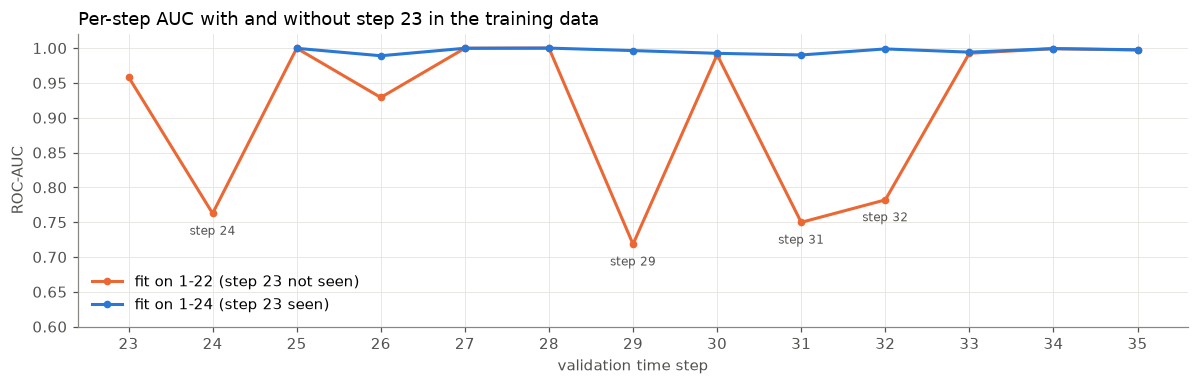

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.6))
a, b = per_step[22], per_step[24]
ax.plot(a.index, a.values, color=C_B, lw=2, marker="o", ms=4, label="fit on 1-22 (step 23 not seen)")
ax.plot(b.index, b.values, color=C_A, lw=2, marker="o", ms=4, label="fit on 1-24 (step 23 seen)")
for s in [24, 29, 31, 32]:
    ax.annotate(f"step {s}", (s, a[s]), xytext=(0, -14), textcoords="offset points", ha="center", fontsize=8, color="#52514e")
ax.set_ylim(0.6, 1.02); ax.set_xticks(range(23, 36))
ax.set_xlabel("validation time step"); ax.set_ylabel("ROC-AUC")
ax.set_title("Per-step AUC with and without step 23 in the training data", loc="left")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

**What we can and cannot say.**

- *What we observe:* without step 23 in training, the model misses many illicit transactions in steps 24, 29, 31
  and 32 (AUC 0.72–0.78). With step 23, it catches them (≥ 0.97). The missed transactions have feature values unlike
  earlier illicit examples, and they are linked to each other in chains.
- *What we do not know:* *why*. It may be a new criminal scheme, one group becoming active, or a change in how
  labels were assigned. The features are anonymised, so we cannot tell.

**Why it matters.** Our original split (fit 1–24 → validate 25–35) puts step 23 into training, so validation never
tested illicit cases unlike the training data. The test period may contain exactly such cases. For the original
Elliptic data, Weber et al. (2019) report that all models fail to detect illicit activity after time step 43, which
they link to a dark-market shutdown. (This assumes our step numbers match the original dataset's. They very likely
do, since the transaction and edge counts match.)

**Fix — a second, harder split:** fit on steps 1–22, validate on 23–35 (`HARD_TRAIN_END` in `src/validation.py`).
Each model now gets two scores: the *standard* split ("familiar patterns") and the *hard* split ("unfamiliar patterns").

**How reliable is it?** So far the hard split predicted one leaderboard result correctly and one wrongly (section 3).
We use it as a guide, not as proof.

## 2. Graph feature: degree

**In-degree** is the number of earlier transactions this one spends money from. **Out-degree** is the number of
later transactions that spend this one's outputs. The EDA showed illicit transactions are more often simple
one-in / one-out links, so degree might help.

Degree is counted on the **full** edge list, including neighbours missing from both files, so it means the same thing
in train and test.

A single run can move by about 0.005–0.009 AUC just by changing the random seed. So we compare *with* vs *without*
degree over **3 seeds × 5 split points** and look at the average difference.

In [4]:
data = train.merge(degree_features(edges, train[ID_COL]), left_on=ID_COL, right_index=True)
DEGREE = ["in_degree", "out_degree"]

rows = []
for seed in [42, 1, 2]:
    for end in [16, 18, 20, 22, 24]:
        without = evaluate(lgbm(seed), FEATURE_COLS, data, train_end=end)["overall_auc"]
        with_deg = evaluate(lgbm(seed), FEATURE_COLS + DEGREE, data, train_end=end)["overall_auc"]
        rows.append({"seed": seed, "fit window": f"1-{end}", "without degree": without,
                     "with degree": with_deg, "difference": with_deg - without})
deg = pd.DataFrame(rows)
print(f"average difference: {deg.difference.mean():+.4f}   (range {deg.difference.min():+.4f} to {deg.difference.max():+.4f})")
deg.pivot_table(index="fit window", columns="seed", values="difference").round(4)

average difference: +0.0004   (range -0.0086 to +0.0091)


seed,1,2,42
fit window,,,
1-16,-0.0036,0.0039,-0.0086
1-18,-0.0025,0.0079,0.0019
1-20,-0.0007,0.0039,0.0010
1-22,-0.0071,0.0006,0.0091
1-24,0.0002,0.0000,-0.0001


**Result: degree does not help.** The average difference is close to zero, and the sign flips between seeds. An
earlier single run showed +0.009 on the hard split, but that was luck with one seed. Degree is **not** used in the
final model.

In [5]:
log_experiment(TODAY, NOTEBOOK, "LightGBM raw + degree (in/out), 3 seeds x 5 splits",
               val_auc=deg[deg["fit window"] == "1-24"]["with degree"].mean(),
               notes=f"mean difference vs raw {deg.difference.mean():+.4f} "
                     f"(range {deg.difference.min():+.4f} to {deg.difference.max():+.4f}); not adopted")

## 3. Other ideas tried and dropped

These were tested in an earlier version of this notebook. Their scores are in `experiments.csv`.

| Idea | Standard split | Hard split | Leaderboard | Verdict |
|---|---|---|---|---|
| LightGBM, all 165 features (reference) | 0.997 | 0.875 | **0.948** | kept |
| + neighbour mean/max of all features | 0.997 | 0.863 | — | dropped: worse on hard split |
| Blend: all 165 + a model on feat_94–165 only | 0.991 | 0.914 | 0.920 | dropped: worse on leaderboard |

- **Neighbour aggregates.** For each transaction we averaged the features of its neighbours. One subtlety: in the
  test period, 46,668 neighbouring transactions are missing from the files (they appear to be that period's unlabeled
  transactions), so a test transaction only "sees" its labeled neighbours. To compute the feature the same way in
  train, we also used labeled neighbours only. Even so, it did not help, probably because the given features already
  summarise each transaction's neighbourhood.
- **Blend with a feat_94–165 model.** A model trained on feat_94–165 only did best on the hard split, so we averaged
  it with the all-features model. It scored 0.920 on the leaderboard, below the plain LightGBM (0.948). The hard split
  favoured it, the leaderboard did not. **Lesson:** the hard split is a useful guide for comparing model *types*
  (it correctly preferred LightGBM over Random Forest), but it misled us when choosing which *features* to use.

## Summary

- Validation looked too good because the standard split lets the model see step 23 before validating. A harder split
  (fit 1–22 → validate 23–35) now sits alongside it.
- Graph features (degree, neighbour aggregates) gave no reliable gain. **The final model uses the 165 raw features.**
- Seed-to-seed noise is about ±0.005–0.009 on the hard split, so later comparisons average over several splits
  (`evaluate_many` in `src/validation.py`).
- Next: compare other model types and tune LightGBM (`05_model_comparison.ipynb`).